# Unemployment in India — Exploratory Data Analysis

This notebook explores the **[Unemployment in India](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india)** dataset (Kaggle), which tracks monthly unemployment rate, number of people employed, and labour participation rate across Indian states from May 2019 to June 2020 — a window that captures the COVID-19 lockdown period.

**Columns (after cleaning/renaming):**
- `State` — Indian state/UT (originally labeled `Region` in the raw file)
- `Date` — month of observation
- `Frequency` — reporting frequency (Monthly)
- `Unemployment Rate` — estimated unemployment rate (%)
- `Employed` — estimated number of people employed
- `Labour Participation Rate` — estimated labour participation rate (%)
- `Region` — Rural / Urban split (originally labeled `Area` in the raw file)

In [1]:
## importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

### Uploading csv

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


#### Dataset Information

In [4]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 46.2 KB


In [8]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [9]:
df.columns = ['State', 'Date', 'Frequency', 'Unemployment Rate',
       'Employed', 'Labour Participation Rate',
       'Region']

In [10]:
df.head()

,State,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Region
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.describe()

,Unemployment Rate,Employed,Labour Participation Rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [12]:
## converting Date column dtype to datetime

In [13]:
df["Date"] = pd.to_datetime(df["Date"] , dayfirst = True)

In [14]:
df["Date"].dtype

dtype('<M8[us]')

In [15]:
df.head()

,State,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Region
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
df["Frequency"] = df["Frequency"].astype("category")

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      740 non-null    str           
 1   Date                       740 non-null    datetime64[us]
 2   Frequency                  740 non-null    category      
 3   Unemployment Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour Participation Rate  740 non-null    float64       
 6   Region                     740 non-null    str           
dtypes: category(1), datetime64[us](1), float64(3), str(2)
memory usage: 41.2 KB


In [18]:
## correlation - method 1 
corr = df.corr(numeric_only = True)
corr

,Unemployment Rate,Employed,Labour Participation Rate
Unemployment Rate,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
Labour Participation Rate,0.002558,0.011300,1.000000


In [19]:
## method 2 
df_corr = df[["Unemployment Rate", "Employed", "Labour Participation Rate"]]
corr2 = df_corr.corr()
corr2

,Unemployment Rate,Employed,Labour Participation Rate
Unemployment Rate,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
Labour Participation Rate,0.002558,0.011300,1.000000


**Observation:** Correlations between the three numeric variables are weak. Unemployment Rate has a mild negative correlation with Employed (-0.22) — unsurprising, since higher unemployment implies fewer people working — while Labour Participation Rate shows almost no linear relationship with either (~0.003 and ~0.01). This suggests participation rate moves fairly independently of how many people are actually employed or unemployed in this dataset.

### Data Visualization

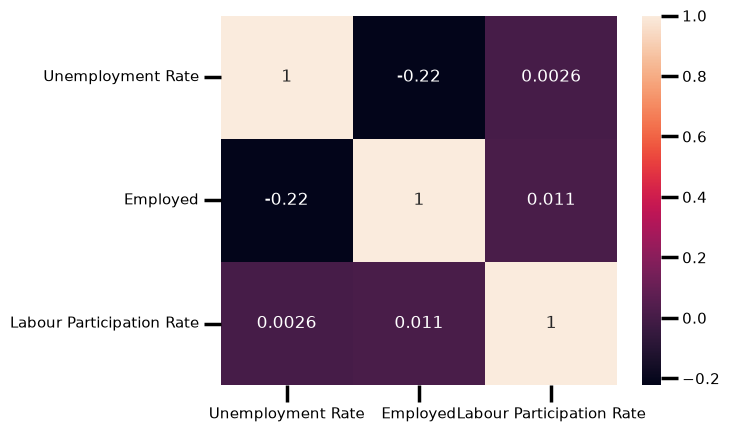

In [20]:
#plt.figure(figsize = (5,3))
sns.set_context("poster", font_scale = 0.5 )
sns.heatmap(corr ,annot = True )
plt.show()

**Observation:** The heatmap confirms the same pattern visually: only the Unemployment–Employed cell stands out (dark, negative), while the rest of the matrix is close to zero — no strong linear relationships to lean on for prediction.

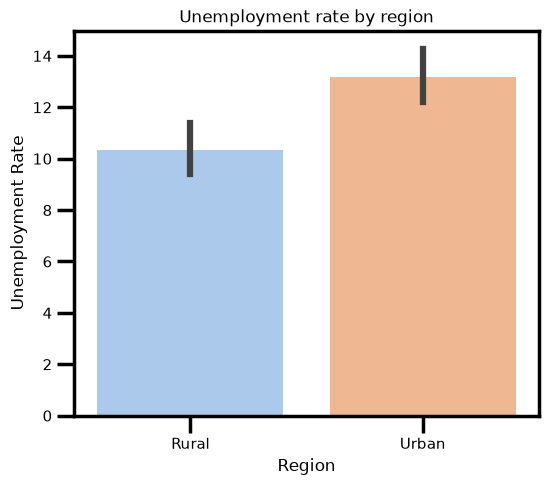

In [21]:
plt.figure(figsize = (6,5))
sns.barplot(x = "Region" , y = "Unemployment Rate" , palette = "pastel" , data = df)
plt.title("Unemployment rate by region")
plt.show()

**Observation:** Urban areas show a noticeably higher average unemployment rate (~13%) than rural areas (~10%) over this period, with non-overlapping confidence intervals — suggesting the gap is fairly consistent rather than due to chance.

In [22]:
data = df.groupby("Region")["Employed"].sum()

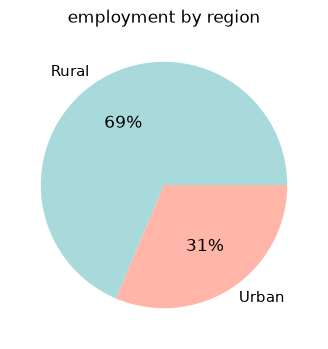

In [23]:
plt.figure(figsize = (6,4))
plt.pie(data , autopct = "%0.0f%%" , labels = data.index , colors = ["#A8DADC" , "#FFB5A7"])
plt.title("employment by region")
plt.show()

**Observation:** Rural areas account for roughly 69% of total employment versus 31% for urban areas. This is expected given rural areas typically report much larger workforces, but it also means rural data points carry more weight in any combined (non-split) statistics elsewhere in this analysis.

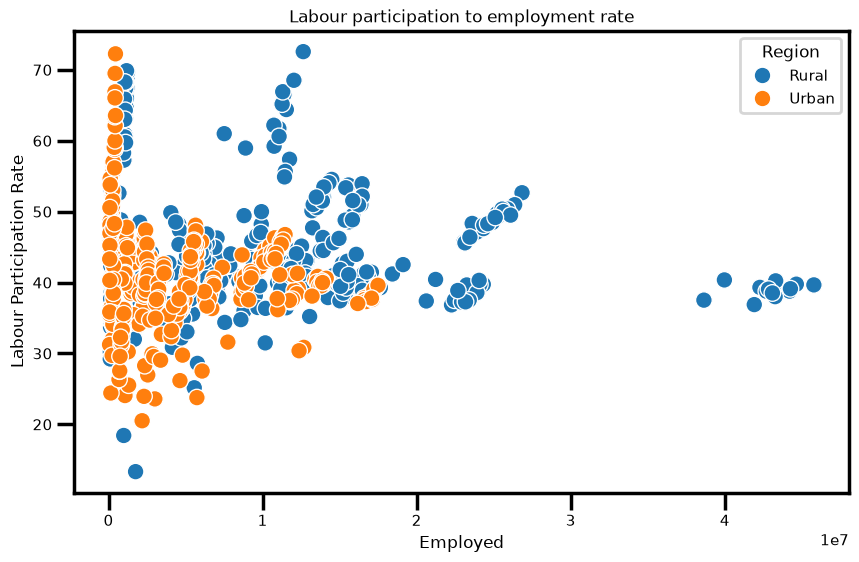

In [24]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df , y = "Labour Participation Rate" , x = "Employed" , hue = "Region")
plt.title("Labour participation to employment rate")
plt.show()

**Observation:** There's no clear linear relationship between number of employed and labour participation rate — points are scattered across the full range of participation (20-70%) regardless of employment level. The handful of high-employment outliers (>2.5 crore) are almost entirely rural states, consistent with the rural employment share seen above.

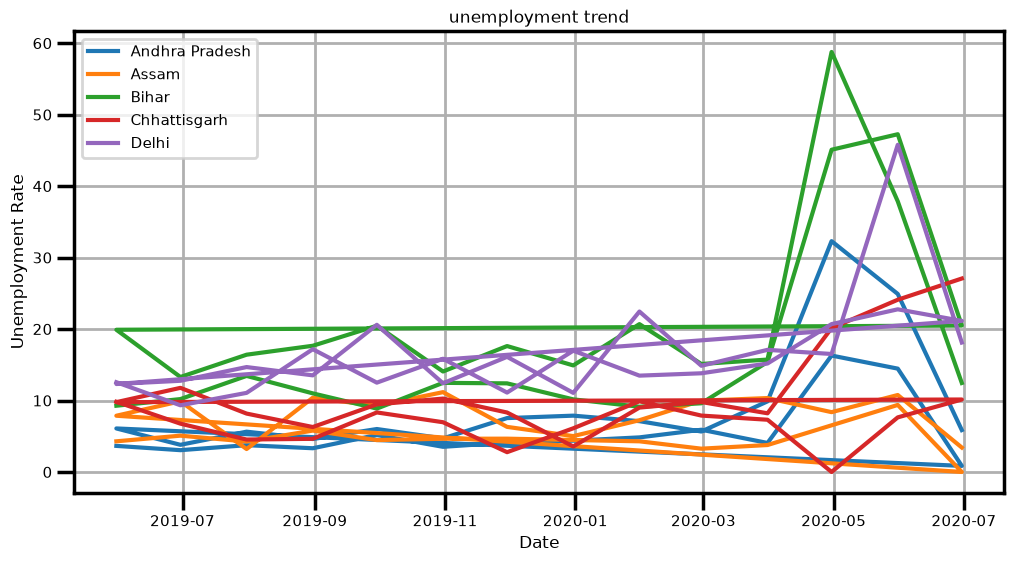

In [25]:
states = df["State"].unique()[:5]
plt.figure(figsize = (12,6))
for s in states :
    data = df[df["State"] == s]
    plt.plot(data["Date"] , data["Unemployment Rate"] , label = s)

plt.title("unemployment trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid()
plt.show()

**Observation:** All five states track relatively flat and close together (single digits to ~20%) until April 2020, when unemployment spikes sharply across the board — this lines up with India's COVID-19 lockdown, which began in late March 2020. Bihar peaks highest (~59%), followed by Delhi (~46%) and Andhra Pradesh (~32%), before rates begin recovering by June 2020.

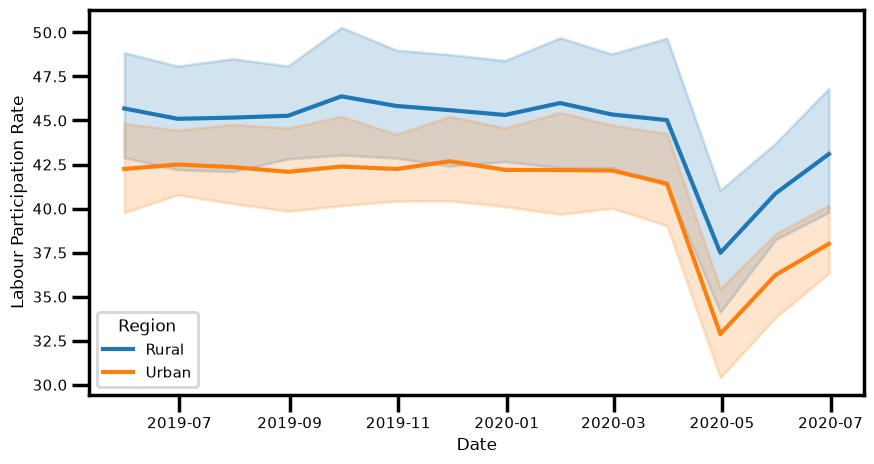

In [26]:
plt.figure(figsize=(10,5))
sns.lineplot(data = df ,
            x = "Date",
            y = "Labour Participation Rate",
            hue = "Region")

plt.show()

**Observation:** Labour participation for both rural and urban areas holds steady around 42-46% through early 2020, then drops sharply in April-May 2020 (rural to ~38%, urban to ~33%) — the same lockdown window that drove the unemployment spike above. Both series partially recover by June/July 2020, though not fully back to pre-lockdown levels.

In [27]:
#df.groupby("State")["Unemployment Rate"].mean().nlargest(5)
top = df.groupby("State")["Unemployment Rate"].mean().sort_values(ascending = False).head()

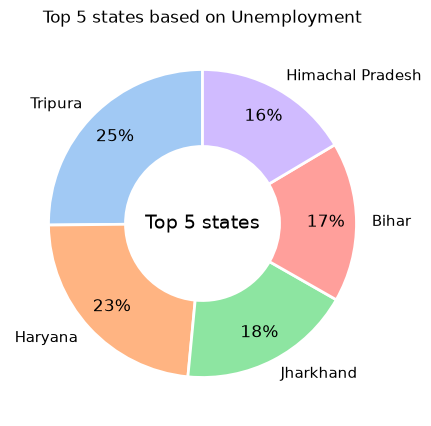

In [28]:
plt.figure(figsize = (6,5))
plt.pie(
    top ,
    autopct = "%0.0f%%" ,
    labels = top.index ,
    colors = sns.color_palette("pastel") ,
    startangle = 90 ,
    wedgeprops = {"edgecolor" : "white" , "width" : 0.5},
    pctdistance = 0.8
)

plt.title("Top 5 states based on Unemployment")
plt.text(0,0, "Top 5 states" , ha = "center" , va = "center" , fontsize = 14)
plt.show()

**Observation:** Tripura (~25%) and Haryana (~24%) account for the largest shares of average unemployment among the top 5 states, followed by Jharkhand (18%), Bihar (17%), and Himachal Pradesh (16%) — together these five states represent the highest sustained unemployment rates in the dataset.

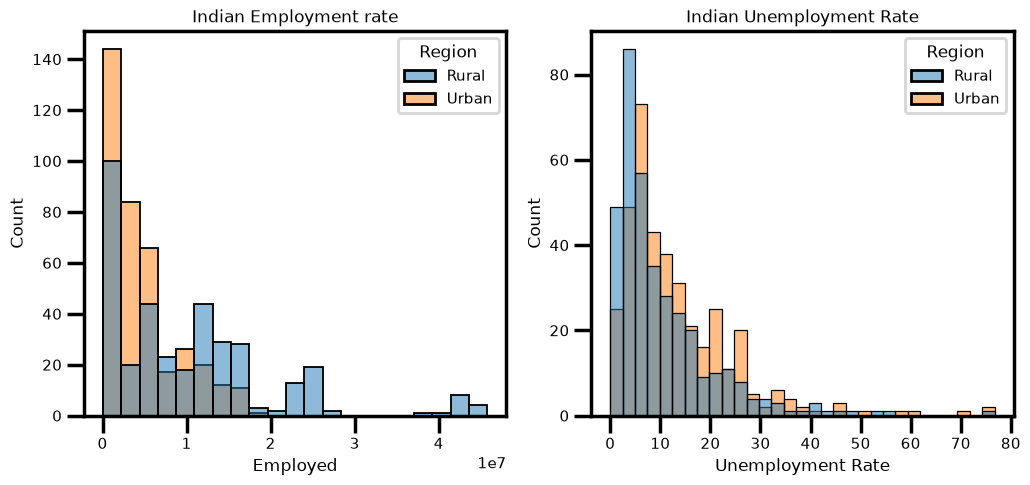

In [29]:
fig , ax = plt.subplots(1 , 2 , figsize = (12,5))
sns.histplot(x="Employed", hue="Region", data=df , ax = ax[0])
ax[0].set_title("Indian Employment rate")
sns.histplot(x="Unemployment Rate", hue="Region", data=df , ax = ax[1])
ax[1].set_title("Indian Unemployment Rate")
plt.show()

**Observation:** Both distributions are strongly right-skewed. Most records cluster at lower employment counts and lower unemployment rates (0-20%), with a long tail — the extreme values above 50-60% unemployment are almost certainly the lockdown-period spikes identified earlier. Urban regions dominate the lowest employment-count bin, while rural regions are more spread across mid-range bins, reflecting the rural/urban employment-scale difference seen in the pie chart.

## Conclusions

- **Weak linear relationships overall:** unemployment, employment, and labour participation rate don't move together in any strong linear way (correlations all under 0.25 in magnitude) — none of these variables reliably predicts another on its own.
- **Urban unemployment runs higher than rural** (~13% vs ~10% on average), even though rural areas account for the majority (69%) of total employment.
- **COVID-19 lockdown (Apr-Jun 2020) is the dominant event in this dataset** — unemployment spikes sharply across every state examined (Bihar and Delhi hit hardest), while labour participation drops in both rural and urban areas over the same window, before partially recovering.
- **Unemployment is unevenly distributed across states:** Tripura, Haryana, Jharkhand, Bihar, and Himachal Pradesh show the highest sustained average unemployment rates in the dataset.
- **Most observations sit in the "normal" range** (low unemployment, moderate employment), with a long right tail driven almost entirely by the lockdown months — worth keeping in mind since these outliers can distort simple averages.

**Possible next steps:** extend the analysis with more recent data (post-2020) to see how much of the lockdown effect persisted, or build a simple time-series forecast for unemployment rate by state.
